In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [ ]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
# Flattening
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)


In [ ]:
# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [ ]:
# function to build model
def build_model():
  model = keras.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
  ])
  return model

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title + " - Accuracy")
    plt.legend()

    plt.show()

In [ ]:
# Baseline model
model_fixed = build_model()

In [ ]:
model_fixed.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9164 - loss: 0.2813 - val_accuracy: 0.9527 - val_loss: 0.1515
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9707 - loss: 0.0964 - val_accuracy: 0.9595 - val_loss: 0.1339
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9808 - loss: 0.0639 - val_accuracy: 0.9676 - val_loss: 0.1158
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9851 - loss: 0.0469 - val_accuracy: 0.9724 - val_loss: 0.0979
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9874 - loss: 0.0374 - val_accuracy: 0.9732 - val_loss: 0.1074
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9905 - loss: 0.0308 - val_accuracy: 0.9753 - val_loss: 0.0967
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9924 - loss: 0.0238 - val_accuracy: 0.9762 - val_loss: 0.0956
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9929 - loss: 0.0208 - val_accuracy: 0.

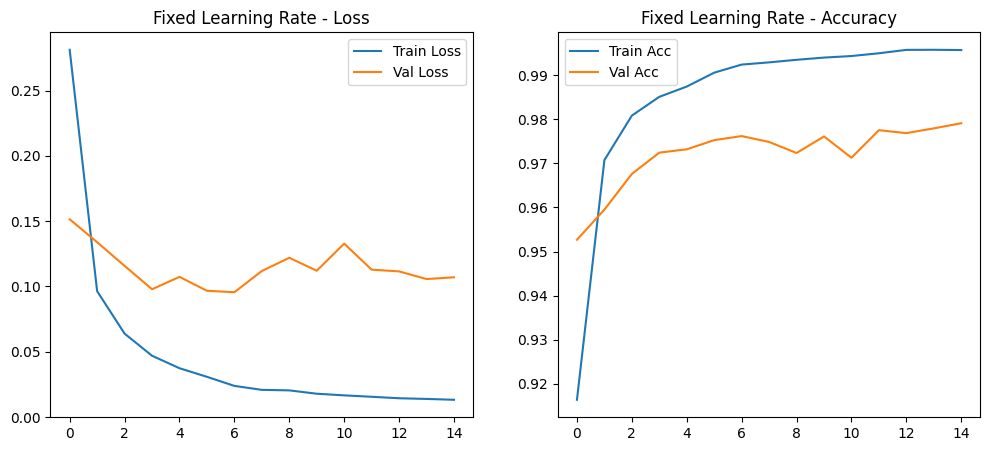

In [ ]:
plot_history(history_fixed, "Fixed Learning Rate")

In [ ]:
class LrLogger(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.lrs = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        self.lrs.append(float(tf.keras.backend.get_value(lr)))

In [ ]:
lr_logger = LrLogger()

In [ ]:
def lr_schedule(epoch, lr):
    if epoch < 5:
        return lr
    else:
        return lr * 0.5

In [ ]:
model_lr = build_model()

In [ ]:
model_lr.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
lr_callback = LearningRateScheduler(lr_schedule)

In [ ]:
# history_lr = model_lr.fit(
#     x_train, y_train,
#     epochs=15,
#     batch_size=128,
#     validation_split=0.2,
#     callbacks=[lr_callback],
#     verbose=1
# )

history_lr = model_lr.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    callbacks=[lr_callback, lr_logger],
    verbose=1
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9215 - loss: 0.2677 - val_accuracy: 0.9533 - val_loss: 0.1502 - learning_rate: 0.0010
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9720 - loss: 0.0946 - val_accuracy: 0.9633 - val_loss: 0.1161 - learning_rate: 0.0010
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9810 - loss: 0.0611 - val_accuracy: 0.9666 - val_loss: 0.1150 - learning_rate: 0.0010
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9858 - loss: 0.0440 - val_accuracy: 0.9725 - val_loss: 0.1098 - learning_rate: 0.0010
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9877 - loss: 0.0387 - val_accuracy: 0.9748 - val_loss: 0.1018 - learning_rate: 0.0010
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9945 - loss: 0.0175 - val_accuracy: 0.9779 - val_loss: 0.0922 - learning_rate: 5.0000e-04
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9985 - loss: 0.006

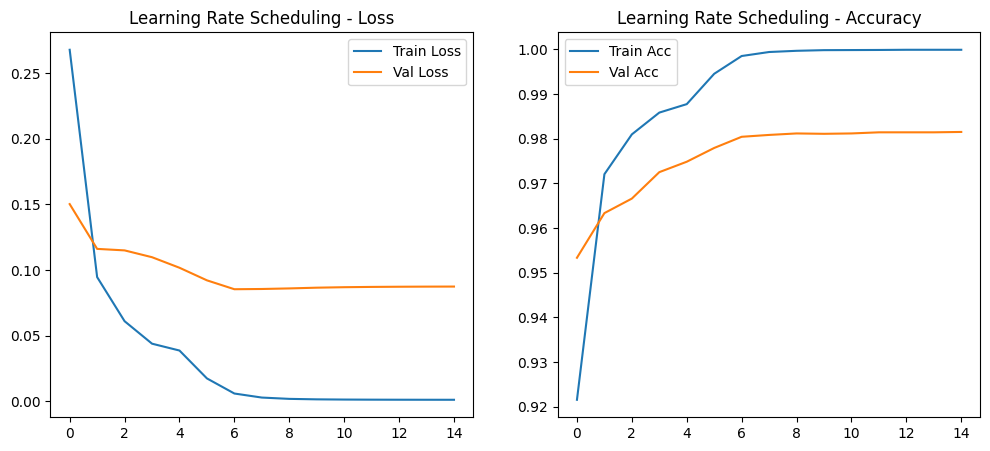

In [ ]:
plot_history(history_lr, "Learning Rate Scheduling")

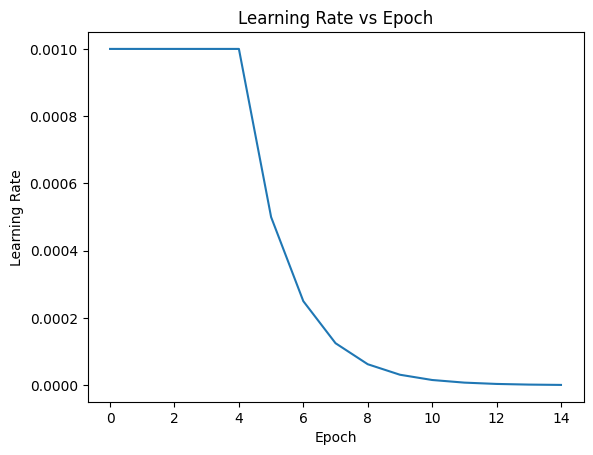

In [ ]:
plt.plot(lr_logger.lrs)
plt.title("Learning Rate vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.show()

In [ ]:
# Early Stopping
model_es = build_model()


In [ ]:
model_es.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,              # stop if no improvement for 3 epochs
    restore_best_weights=True
)

In [ ]:
history_es = model_es.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9217 - loss: 0.2716 - val_accuracy: 0.9525 - val_loss: 0.1535
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9708 - loss: 0.0960 - val_accuracy: 0.9625 - val_loss: 0.1237
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9813 - loss: 0.0621 - val_accuracy: 0.9665 - val_loss: 0.1193
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9851 - loss: 0.0459 - val_accuracy: 0.9736 - val_loss: 0.1005
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9886 - loss: 0.0365 - val_accuracy: 0.9753 - val_loss: 0.0961
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9901 - loss: 0.0305 - val_accuracy: 0.9762 - val_loss: 0.0963
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9920 - loss: 0.0244 - val_accuracy: 0.9777 - val_loss: 0.1009
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9921 - loss: 0.0248 - val_accuracy: 0.

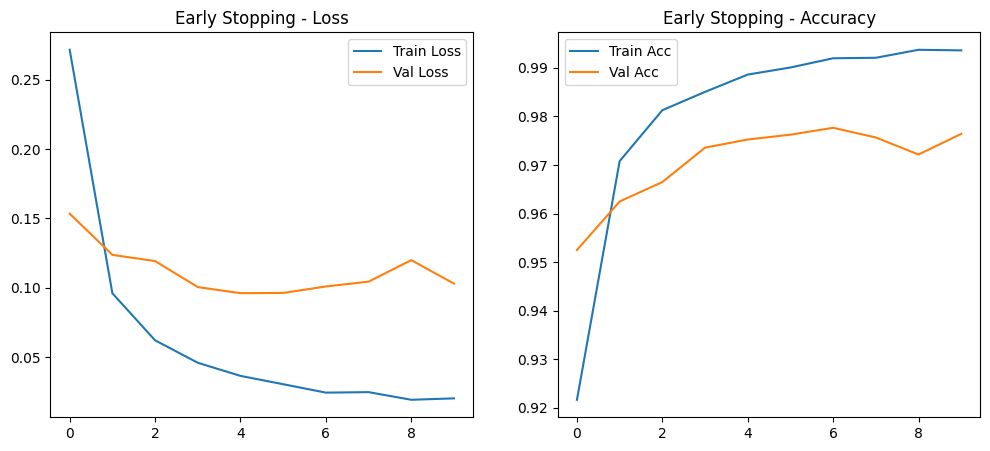

In [ ]:
plot_history(history_es, "Early Stopping")

In [ ]:
print("Fixed LR Final Accuracy:",
      history_fixed.history['val_accuracy'][-1])

print("LR Scheduling Final Accuracy:",
      history_lr.history['val_accuracy'][-1])

print("Early Stopping Final Accuracy:",
      history_es.history['val_accuracy'][-1])

print("Epochs run (Early Stopping):",
      len(history_es.history['loss']))

Fixed LR Final Accuracy: 0.9790833592414856
LR Scheduling Final Accuracy: 0.9815000295639038
Early Stopping Final Accuracy: 0.9764166474342346
Epochs run (Early Stopping): 10
